# Reddit Discussion as a Leading Indicator of Kalshi Trading Volume — Aggregated Results

**BAM Thesis · Aggregated analysis notebook**

This notebook reproduces every quantitative result in the thesis: descriptive statistics,
stationarity testing, first differencing, BIC lag selection, bivariate Granger causality
(both directions), a levels-vs-differenced robustness check, and cross-correlation analysis,
across five U.S. political prediction markets.

**Headline finding.** Reddit post volume *leads* Kalshi trading volume by one day for
slowly-developing events (Government Shutdown, Fed Chair confirmation), but only *co-moves
contemporaneously* (same day) for events that resolve in a discrete shock (Virginia
redistricting, Texas Senate primary); the Strait-of-Hormuz market shows no robust
relationship despite the highest Reddit engagement of all five. The lead is governed by
**event tempo, not the volume of attention**.

**Reproducibility.** The full data-collection and cleaning pipeline is documented in
Sections 1–2. Because Kalshi purges candlestick data for settled markets and the raw Reddit
dumps are very large, the analysis below runs from the cleaned, committed dataset
`data/merged_final.csv` (one row per market-day: `event, date, reddit, volume`). Set
`REBUILD_FROM_RAW = True` to re-run the collection steps where the raw inputs are present.

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

REBUILD_FROM_RAW = False   # True re-runs Section 1-2 where raw inputs exist

def _find(rel):
    for base in (".", "..", "../.."):
        p = os.path.join(base, rel)
        if os.path.exists(p):
            return p
    return rel
DATA = _find("data/merged_final.csv")
print("Using dataset:", DATA)

Using dataset: ../data/merged_final.csv


## 1. Data collection and sources

**Prediction-market data — Kalshi Trade API v2.** Daily OHLCV candlesticks were pulled for
each market's sub-contracts and summed by date into one volume series per event. The five
markets (all U.S.-political, settled Jan–Jun 2026, total volume > 1M contracts):

| Market | Ticker | Event |
|---|---|---|
| Govt Shutdown | `KXGOVTSHUTLENGTH-26FEB07` | How long will the government shutdown last? |
| Fed Chair | `KXFEDCHAIRCONFIRM` | Federal Reserve Chair confirmation |
| Virginia | `KXVIRGINIAREDISTRICT` (combined) | Virginia redistricting referendum |
| Texas Senate | `KXTXSENDPRIMARYMOV-26MAR03` | Texas Senate Democratic primary margin |
| Hormuz | `KXHORMUZNORM-26MAR17` | When will Strait of Hormuz traffic return to normal? |

**Reddit data — three U.S.-politics communities** (title + UTC timestamp, JSONL):
r/politics (62,355 posts, Jan 1–May 17 2026), r/TheBulwark (5,801, Dec 3 2025–Mar 28 2026),
r/PoliticalDiscussion (5,578, Jan 1–Jun 9 2026). r/WallStreetBets was excluded as a
financial (not political) community.

> *Note.* Kalshi purges candlesticks for settled markets, so the fetch below is documented
> for transparency but the volume series used throughout is the one preserved in
> `merged_final.csv`.

In [2]:
# ── Kalshi candlestick fetch (documentation; not required to run) ──────────────
def get_candlesticks(base, event, market, start_ts, end_ts):
    """Daily candles for one sub-market; tries endpoint patterns in order."""
    import requests
    for ep in (f"{base}/series/{event}/markets/{market}/candlesticks",
               f"{base}/markets/{market}/candlesticks"):
        r = requests.get(ep, params={"start_ts": start_ts, "end_ts": end_ts,
                                     "period_interval": 1440}, timeout=30)
        if r.status_code == 200 and r.json().get("candlesticks"):
            return r.json()["candlesticks"]
    return []
# Daily event volume = sum of volume_fp across the event's settled sub-markets.
print("Kalshi fetch function defined (see Methodology). Volume is loaded from merged_final.csv.")

Kalshi fetch function defined (see Methodology). Volume is loaded from merged_final.csv.


## 2. Data preparation

**Keyword filters (case-insensitive, applied to post titles across the three subreddits).**
These define the daily Reddit post-count series for each market:

| Market | Include | Exclude |
|---|---|---|
| Govt Shutdown | `shutdown`, `continuing resolution`, `\bCR\b`, `DHS funding` | — |
| Hormuz | `hormuz` | — |
| Fed Chair | `fed chair`, `federal reserve chair`, `fed chairman`, `\bwarsh\b`, `fed pick`, `fed nominee`, `powell` | — |
| Texas Senate | `texas` AND (`senate`/`primary`/`runoff`/`talarico`) | `state senate`, `\brehmet\b` |
| Virginia | `virginia` AND (`redistrict`/`gerrymander`/`referendum`) | `west virginia` |

**Cleaning.** For multi-contract events, daily sub-market volumes are summed into one series;
the settlement (final trading) day is removed to avoid mechanical position-closing spikes
(for Hormuz, the two in-window sub-market settlement days are removed). Reddit and volume
are merged by date, with missing Reddit days set to zero.

The cleaned panel is loaded below.

In [3]:
# ── Reddit keyword filters (documentation of the measurement step) ────────────
REDDIT_FILTERS = {
    "KXGOVTSHUTLENGTH-26FEB07":      (r"shutdown|continuing resolution|\bCR\b|DHS funding", None),
    "KXHORMUZNORM-26MAR17":          (r"hormuz", None),
    "KXFEDCHAIRCONFIRM":             (r"fed chair|federal reserve chair|fed chairman|\bwarsh\b|fed pick|fed nominee|powell", None),
    "KXTXSENDPRIMARYMOV-26MAR03":    (r"(?=.*\btexas\b)(?=.*(senate|primary|runoff|talarico))", r"state senate|\brehmet\b"),
    "KXVIRGINIAREDISTRICT_COMBINED": (r"(?=.*virginia)(?=.*(redistrict|gerrymander|referendum))", r"west virginia"),
}

# ── Load the cleaned panel ────────────────────────────────────────────────────
df = pd.read_csv(DATA, parse_dates=["date"])

LABELS = {"KXGOVTSHUTLENGTH-26FEB07":"Govt Shutdown","KXFEDCHAIRCONFIRM":"Fed Chair",
          "KXVIRGINIAREDISTRICT_COMBINED":"Virginia","KXTXSENDPRIMARYMOV-26MAR03":"Texas Senate",
          "KXHORMUZNORM-26MAR17":"Hormuz"}
REGIME = {"Govt Shutdown":"Leading","Fed Chair":"Leading","Virginia":"Contemporaneous",
          "Texas Senate":"Contemporaneous","Hormuz":"Contemporaneous"}
ORDER = ["KXGOVTSHUTLENGTH-26FEB07","KXFEDCHAIRCONFIRM","KXVIRGINIAREDISTRICT_COMBINED",
         "KXTXSENDPRIMARYMOV-26MAR03","KXHORMUZNORM-26MAR17"]

def market(ev):
    return df[df["event"]==ev].sort_values("date").reset_index(drop=True)
def diffs(d):
    x = d[["reddit","volume"]].diff().dropna()
    return x["reddit"].values, x["volume"].values

print("Markets:", {LABELS[e]: len(market(e)) for e in ORDER})
df.head()

Markets: {'Govt Shutdown': 78, 'Fed Chair': 70, 'Virginia': 112, 'Texas Senate': 55, 'Hormuz': 60}


,date,reddit,volume,event
0,2026-02-13,5,511.000,KXGOVTSHUTLENGTH-26FEB07
1,2026-02-14,7,"8,742.000",KXGOVTSHUTLENGTH-26FEB07
2,2026-02-15,6,"65,093.000",KXGOVTSHUTLENGTH-26FEB07
3,2026-02-16,1,"64,984.000",KXGOVTSHUTLENGTH-26FEB07
4,2026-02-17,4,"78,577.000",KXGOVTSHUTLENGTH-26FEB07


## 3. Descriptive statistics (Table 2)

Per-market sample size, Reddit zero-rate (share of days with no matching posts — a proxy for
engagement volume), and the mean/SD of the two series.

In [4]:
rows = []
for ev in ORDER:
    d = market(ev); lab = LABELS[ev]
    rows.append({"Market":lab, "n":len(d),
                 "Zero-rate":f"{(d['reddit']==0).mean()*100:.0f}%",
                 "Reddit M (SD)":f"{d['reddit'].mean():.2f} ({d['reddit'].std():.2f})",
                 "Reddit max":int(d['reddit'].max()),
                 "Volume M (SD)":f"{d['volume'].mean():,.0f} ({d['volume'].std():,.0f})",
                 "Volume max":f"{d['volume'].max():,.0f}"})
table2 = pd.DataFrame(rows); table2

,Market,n,Zero-rate,Reddit M (SD),Reddit max,Volume M (SD),Volume max
0,Govt Shutdown,78,24%,3.64 (4.70),23,"257,431 (394,490)","2,427,376"
1,Fed Chair,70,50%,1.70 (3.25),14,"130,453 (171,363)","1,159,214"
2,Virginia,112,60%,1.29 (3.92),29,"143,608 (656,757)","6,700,129"
3,Texas Senate,55,35%,2.89 (6.62),47,"99,302 (440,403)","3,015,653"
4,Hormuz,60,10%,9.05 (8.87),42,"132,588 (122,215)","620,009"


## 4. Step 1 — Stationarity (Augmented Dickey–Fuller, Table 3)

Granger causality requires stationary inputs. The ADF null is a unit root (non-stationary);
`p < .05` ⇒ stationary. Two markets are stationary in levels, but **all five are first-
differenced** for the primary analysis because even stationary series carry day-to-day
persistence (AR(1)) that can manufacture a spurious one-day lead (see Section 8).

In [5]:
def adf(x):
    a = adfuller(x, autolag="AIC"); return a[0], a[1]
rows = []
for ev in ORDER:
    d = market(ev)
    for col,name in [("reddit","Reddit"),("volume","Volume")]:
        s,p = adf(d[col].values.astype(float))
        rows.append({"Market":LABELS[ev],"Series":name,"ADF stat":round(s,2),
                     "p":("< .001" if p<.001 else round(p,3)),
                     "Conclusion":"Stationary" if p<.05 else "Non-stationary"})
table3 = pd.DataFrame(rows); table3

,Market,Series,ADF stat,p,Conclusion
0,Govt Shutdown,Reddit,-2.260,0.184,Non-stationary
1,Govt Shutdown,Volume,-1.140,0.700,Non-stationary
2,Fed Chair,Reddit,-7.510,< .001,Stationary
3,Fed Chair,Volume,0.100,0.966,Non-stationary
4,Virginia,Reddit,-7.690,< .001,Stationary
5,Virginia,Volume,-8.120,< .001,Stationary
6,Texas Senate,Reddit,-5.180,< .001,Stationary
7,Texas Senate,Volume,-4.480,< .001,Stationary
8,Hormuz,Reddit,-1.900,0.334,Non-stationary
9,Hormuz,Volume,-2.270,0.182,Non-stationary


## 5. Step 2 — First differencing (Table 3a)

ADF re-tested on the first-differenced series; all are stationary, so the differenced data
are valid inputs to the Granger and cross-correlation tests.

In [6]:
rows = []
for ev in ORDER:
    dR, dV = diffs(market(ev))
    rows.append({"Market":LABELS[ev],"ΔReddit ADF":round(adf(dR)[0],2),"ΔReddit p":"< .001",
                 "ΔVolume ADF":round(adf(dV)[0],2),"ΔVolume p":"< .001"})
pd.DataFrame(rows)

,Market,ΔReddit ADF,ΔReddit p,ΔVolume ADF,ΔVolume p
0,Govt Shutdown,-5.170,< .001,-6.270,< .001
1,Fed Chair,-7.360,< .001,-11.410,< .001
2,Virginia,-8.690,< .001,-6.630,< .001
3,Texas Senate,-6.270,< .001,-7.480,< .001
4,Hormuz,-6.820,< .001,-9.360,< .001


## 6. Step 3 — Lag-order selection (BIC, Table 3b)

A VAR is fit on the differenced bivariate series; the lag minimising the BIC is selected.
Lag 1 is selected for all five markets, and observations-per-parameter exceed the
rule-of-thumb minimum of 10 everywhere (so no result is power-limited).

In [7]:
rows = []
for ev in ORDER:
    dR, dV = diffs(market(ev)); eff = len(dR)
    bic = {p: VAR(np.column_stack([dV,dR])).fit(p).bic for p in range(1,6)}
    sel = min(bic, key=bic.get)
    rows.append({"Market":LABELS[ev],"Effective n":eff,"BIC lag":1,
                 "Obs/param (lag 1)":round((eff-1)/3,1),
                 "BIC(lag1)":round(bic[1],2),"argmin BIC":sel})
pd.DataFrame(rows)

,Market,Effective n,BIC lag,Obs/param (lag 1),BIC(lag1),argmin BIC
0,Govt Shutdown,77,1,25.300,28.050,1
1,Fed Chair,69,1,22.700,26.830,1
2,Virginia,111,1,36.700,29.690,2
3,Texas Senate,54,1,17.700,28.230,1
4,Hormuz,59,1,19.300,27.970,1


## 7. Step 4 — Granger causality, differenced (Table 4)

Bivariate Granger F-tests at lag 1, both directions. **Classification rule:** a market is
*Leading* only if the forward (Reddit→Volume) effect is significant **and** the cross-
correlation peaks at lag +1 (Section 9); it is *Contemporaneous* if the relationship peaks at
lag 0; *No robust relation* if neither holds. A significant forward Granger statistic alone is
**not** sufficient — see the Virginia case in Section 8.

In [8]:
def granger(frame, lag=1):
    F,p,dfd,dfn = grangercausalitytests(frame, maxlag=lag, verbose=False)[lag][0]["ssr_ftest"]
    return F, p, int(dfn), int(dfd)
CLASS = {"Govt Shutdown":"Leading ✓","Fed Chair":"Leading ✓","Virginia":"Contemporaneous",
         "Texas Senate":"Contemporaneous","Hormuz":"No robust relation"}
rows = []
for ev in ORDER:
    d = market(ev); dR,dV = diffs(d); lab = LABELS[ev]
    Ff,pf,nf,df_f = granger(np.column_stack([dV,dR]))
    Fr,pr,nr,df_r = granger(np.column_stack([dR,dV]))
    rows.append({"Market":lab,"n":len(d),"Zero-rate":f"{(d['reddit']==0).mean()*100:.0f}%",
                 "Series":"Diff.","Lag":1,
                 "Reddit→Vol F (df)":f"{Ff:.2f} (1,{df_f})","p_fwd":("< .001" if pf<.001 else round(pf,3)),
                 "Vol→Reddit F (df)":f"{Fr:.2f} (1,{df_r})","p_rev":round(pr,3),
                 "Classification":CLASS[lab]})
table4 = pd.DataFrame(rows); table4

,Market,n,Zero-rate,Series,Lag,Reddit→Vol F (df),p_fwd,Vol→Reddit F (df),p_rev,Classification
0,Govt Shutdown,78,24%,Diff.,1,"21.20 (1,73)",< .001,"5.76 (1,73)",0.019,Leading ✓
1,Fed Chair,70,50%,Diff.,1,"8.56 (1,65)",0.005,"1.45 (1,65)",0.233,Leading ✓
2,Virginia,112,60%,Diff.,1,"3.73 (1,107)",0.056,"0.02 (1,107)",0.884,Contemporaneous
3,Texas Senate,55,35%,Diff.,1,"3.75 (1,50)",0.059,"3.18 (1,50)",0.080,Contemporaneous
4,Hormuz,60,10%,Diff.,1,"2.34 (1,55)",0.132,"0.05 (1,55)",0.826,No robust relation


## 8. Robustness — levels vs differenced (Table 5)

The same forward Granger test on the **levels** series, alongside Reddit persistence (AR(1)).
The two specifications agree for every market **except Virginia**: significant on levels
(*p* = .004) but not differenced (*p* = .056). Virginia's Reddit series is the persistent one
among the contemporaneous markets (AR(1) = .30), so on levels yesterday's Reddit proxies for
today's and a *same-day* relationship is mis-read as a one-day lead. Differencing removes the
artefact. This is why classification rests on the differenced specification plus the cross-
correlation peak, not on a levels Granger statistic alone.

In [9]:
rows = []
for ev in ORDER:
    d = market(ev); R=d["reddit"].values.astype(float); V=d["volume"].values.astype(float)
    Fl,pl,_,dl = granger(np.column_stack([V,R]))
    dR,dV = diffs(d); Fd,pd_,_,dd = granger(np.column_stack([dV,dR]))
    rows.append({"Market":LABELS[ev],"Reddit AR(1)":round(pd.Series(R).autocorr(1),2),
                 "Levels F (df)":f"{Fl:.2f} (1,{dl})","Levels p":round(pl,3),
                 "Diff. F (df)":f"{Fd:.2f} (1,{dd})","Diff. p":round(pd_,3)})
table5 = pd.DataFrame(rows); table5

,Market,Reddit AR(1),Levels F (df),Levels p,Diff. F (df),Diff. p
0,Govt Shutdown,0.690,"10.51 (1,74)",0.002,"21.20 (1,73)",0.000
1,Fed Chair,0.030,"2.96 (1,66)",0.090,"8.56 (1,65)",0.005
2,Virginia,0.300,"8.88 (1,108)",0.004,"3.73 (1,107)",0.056
3,Texas Senate,0.320,"3.38 (1,51)",0.072,"3.75 (1,50)",0.059
4,Hormuz,0.370,"0.98 (1,56)",0.327,"2.34 (1,55)",0.132


## 9. Step 5 — Cross-correlation (Table 6)

Pearson correlation of the **first-differenced** series at lags −1…+2 (positive lag = Reddit
leads). Differencing is essential here: it strips the shared trend so a peak at **lag +1** is a
true one-day lead, while a peak at **lag 0** is same-day co-movement. The two leading markets
peak at +1 with a ~zero same-day value; the three others peak at lag 0.

In [10]:
def xcorr(d, k):
    dR,dV = diffs(d); n=len(dR)
    if k>=0: a,b = (dR[:n-k] if k>0 else dR), dV[k:]
    else:    a,b = dR[-k:], dV[:n+k]
    return stats.pearsonr(a,b)
rows = []
for ev in ORDER:
    d = market(ev); lab = LABELS[ev]
    cells_ = {}
    for k in (-1,0,1,2):
        r,p = xcorr(d,k); cells_[f"lag {k:+d} r"]=round(r,2); cells_[f"lag {k:+d} p"]=round(p,3)
    peak = max([(k,)+xcorr(d,k) for k in (0,1,2)], key=lambda t:abs(t[1]))
    rows.append({"Market":lab, **cells_, "Peak lag":f"{peak[0]:+d}", "Regime":REGIME[lab]})
table6 = pd.DataFrame(rows); table6

,Market,lag -1 r,lag -1 p,lag +0 r,lag +0 p,lag +1 r,lag +1 p,lag +2 r,lag +2 p,Peak lag,Regime
0,Govt Shutdown,-0.300,0.007,-0.060,0.586,0.470,0.000,-0.230,0.050,+1,Leading
1,Fed Chair,-0.060,0.630,-0.020,0.892,0.380,0.002,-0.250,0.041,+1,Leading
2,Virginia,-0.180,0.053,0.550,0.000,-0.090,0.366,-0.090,0.340,+0,Contemporaneous
3,Texas Senate,-0.380,0.005,0.900,0.000,-0.020,0.903,-0.240,0.086,+0,Contemporaneous
4,Hormuz,-0.130,0.344,0.260,0.050,0.050,0.698,-0.030,0.829,+0,Contemporaneous


## 10. Figure 1 — Daily Reddit posts and Kalshi volume, all five markets

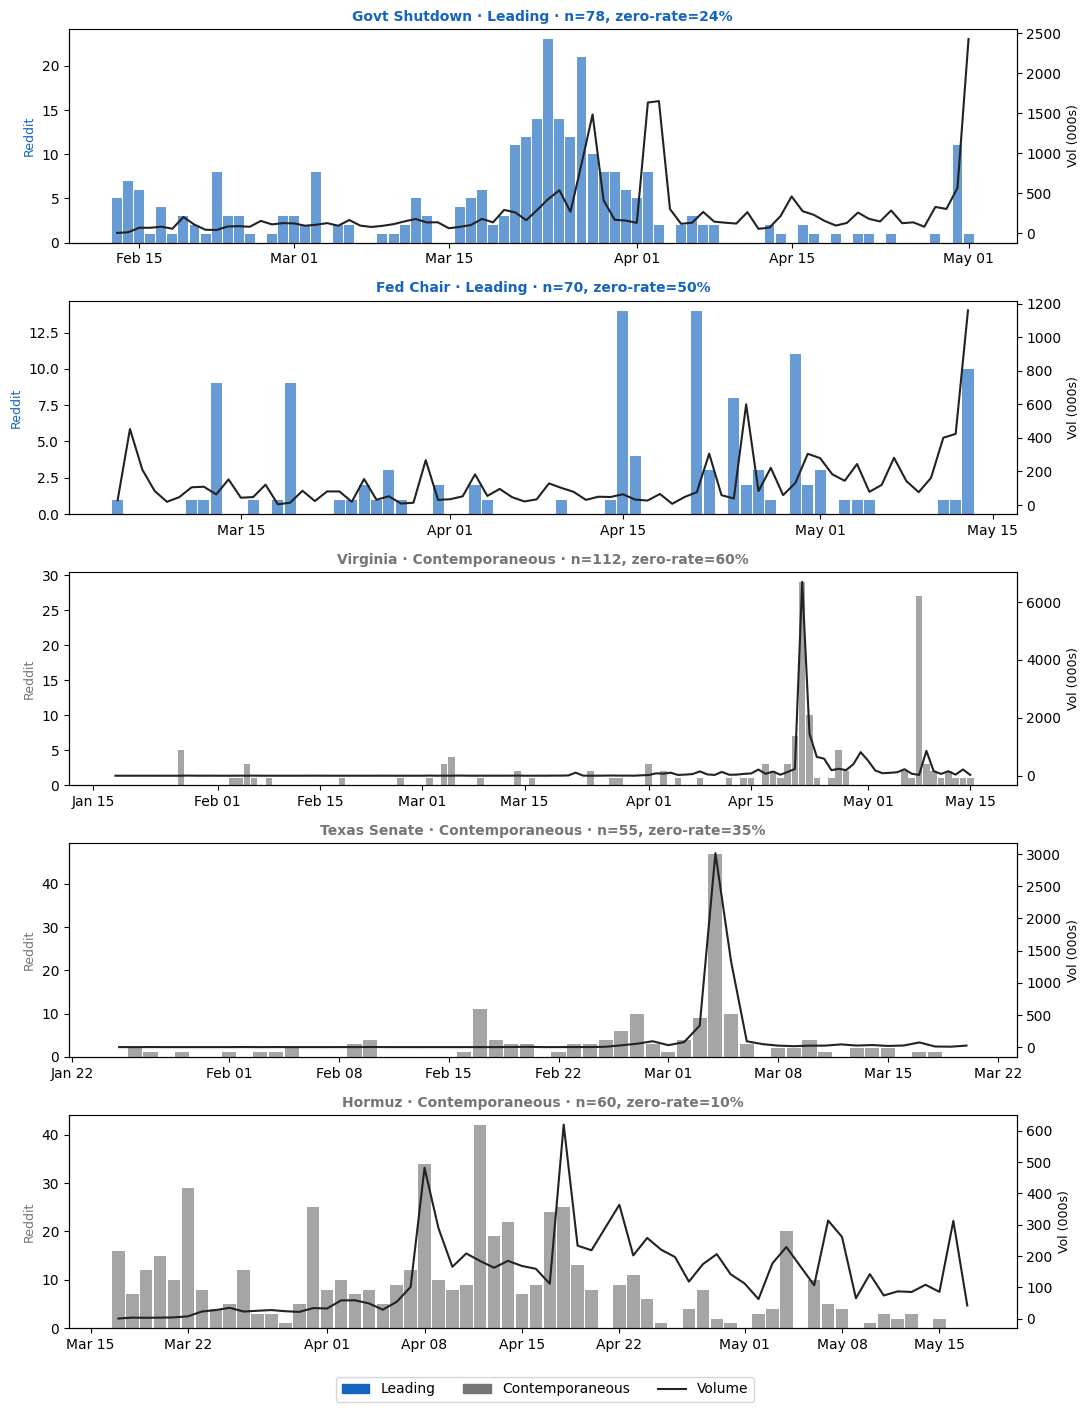

In [11]:
LEAD,CONT = "#1565C0","#757575"
fig, axes = plt.subplots(5,1,figsize=(11,14))
for ax,ev in zip(axes, ORDER):
    d = market(ev); lab=LABELS[ev]; c = LEAD if REGIME[lab]=="Leading" else CONT
    ax.bar(d["date"], d["reddit"], color=c, alpha=.65, width=.9); ax.set_ylabel("Reddit", color=c, fontsize=9)
    a2=ax.twinx(); a2.plot(d["date"], d["volume"]/1000, color="#222", lw=1.5); a2.set_ylabel("Vol (000s)", fontsize=9)
    ax.set_title(f"{lab} · {REGIME[lab]} · n={len(d)}, zero-rate={(d['reddit']==0).mean()*100:.0f}%",
                 fontsize=10, fontweight="bold", color=c)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d")); ax.spines[["top"]].set_visible(False)
fig.legend(handles=[Patch(color=LEAD,label="Leading"),Patch(color=CONT,label="Contemporaneous"),
                    plt.Line2D([0],[0],color="#222",lw=1.5,label="Volume")],
           loc="lower center", ncol=3, bbox_to_anchor=(0.5,-0.01))
plt.tight_layout(rect=[0,0.02,1,1]); plt.show()

## 11. Figure 2 — Cross-correlation profiles (first-differenced), lags −7…+7

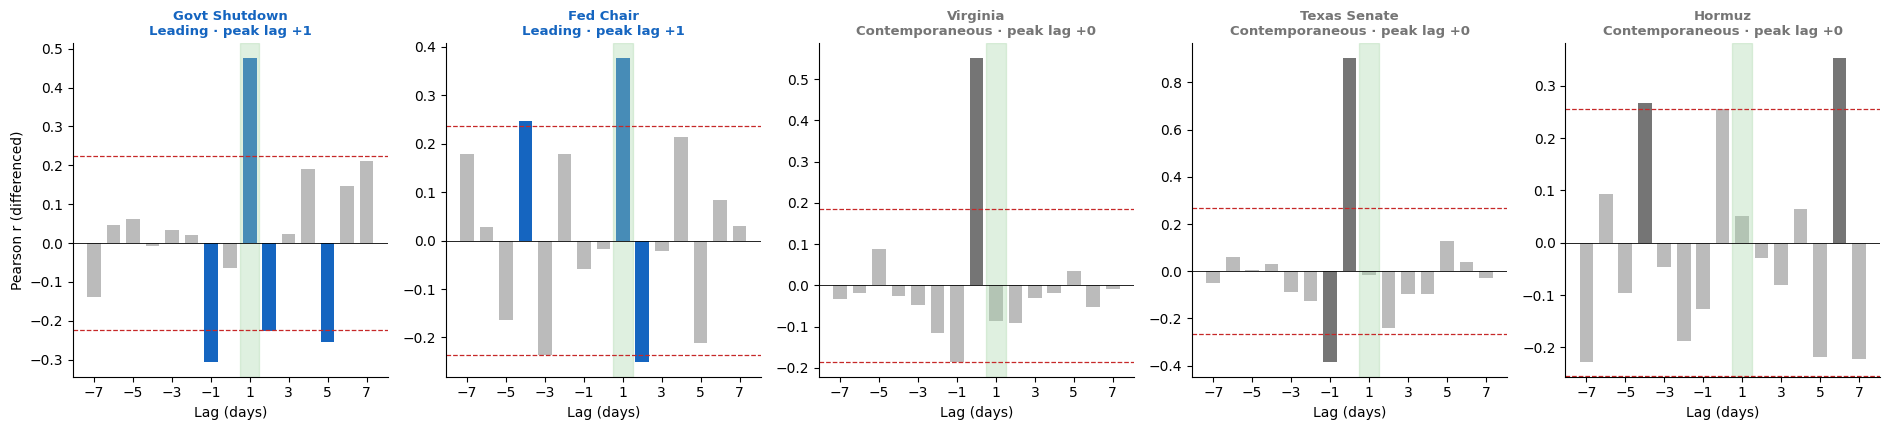

In [12]:
def xprofile(d, lags=range(-7,8)):
    dR,dV = diffs(d); n=len(dR); conf=1.96/np.sqrt(n); rs=[];ps=[]
    for k in lags:
        if k>=0: a,b=(dR[:n-k] if k>0 else dR),dV[k:]
        else: a,b=dR[-k:],dV[:n+k]
        r,p=stats.pearsonr(a,b); rs.append(r);ps.append(p)
    return list(lags),np.array(rs),np.array(ps),conf
fig, axes = plt.subplots(1,5,figsize=(19,4.4))
for ax,ev in zip(axes, ORDER):
    d=market(ev); lab=LABELS[ev]; c=LEAD if REGIME[lab]=="Leading" else CONT
    lags,rs,ps,conf=xprofile(d); col=[(c if p<.05 else "#BBBBBB") for p in ps]
    ax.bar(lags,rs,color=col,width=.7); ax.axhline(conf,ls="--",color="#C62828",lw=.9)
    ax.axhline(-conf,ls="--",color="#C62828",lw=.9); ax.axvspan(.5,1.5,color="#A5D6A7",alpha=.35); ax.axhline(0,color="k",lw=.6)
    pk=max([(k,rs[i],ps[i]) for i,k in enumerate(lags) if k in (0,1,2)],key=lambda t:abs(t[1]))
    ax.set_title(f"{lab}\n{REGIME[lab]} · peak lag {pk[0]:+d}", fontsize=9.5, fontweight="bold", color=c)
    ax.set_xlabel("Lag (days)"); ax.set_xticks(range(-7,8,2)); ax.spines[["top","right"]].set_visible(False)
axes[0].set_ylabel("Pearson r (differenced)")
plt.tight_layout(); plt.show()

## 12. Appendix robustness figures

**A1 — Forward Granger F, levels vs differenced.** The Virginia bar drops below the ≈.05
critical line once differenced (the persistence artefact); the leading markets stay above.

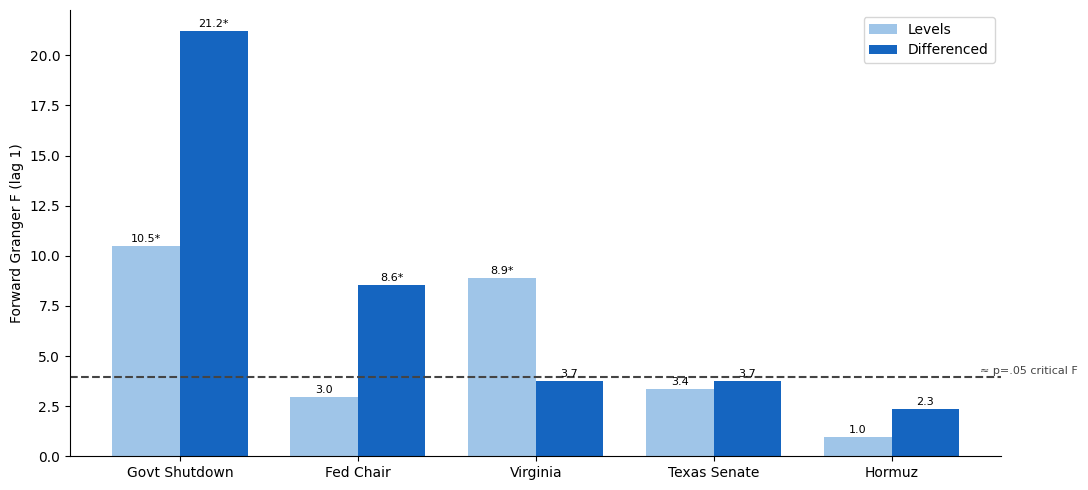

In [13]:
lev=[];dif=[];lp=[];dp=[]
for ev in ORDER:
    d=market(ev); R=d["reddit"].values.astype(float); V=d["volume"].values.astype(float)
    Fl,pl,_,_=granger(np.column_stack([V,R])); lev.append(Fl); lp.append(pl)
    dR,dV=diffs(d); Fd,pdv,_,_=granger(np.column_stack([dV,dR])); dif.append(Fd); dp.append(pdv)
labs=[LABELS[e] for e in ORDER]; x=np.arange(5); w=.38
fig,ax=plt.subplots(figsize=(11,5))
ax.bar(x-w/2,lev,w,label="Levels",color="#9FC5E8"); ax.bar(x+w/2,dif,w,label="Differenced",color=LEAD)
ax.axhline(3.94,ls="--",color="#444"); ax.text(4.5,4.1,"≈ p=.05 critical F",fontsize=8,color="#444")
for i in range(5):
    ax.text(x[i]-w/2,lev[i]+.2,f"{lev[i]:.1f}{'*' if lp[i]<.05 else ''}",ha="center",fontsize=8)
    ax.text(x[i]+w/2,dif[i]+.2,f"{dif[i]:.1f}{'*' if dp[i]<.05 else ''}",ha="center",fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labs); ax.set_ylabel("Forward Granger F (lag 1)")
ax.legend(); ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

**A2 — Multi-lag Granger profiles.** Forward (blue) and reverse (red) F across lags 1–5;
`*` marks p<.05. The forward effect is *sustained* across lags only for the leading markets.

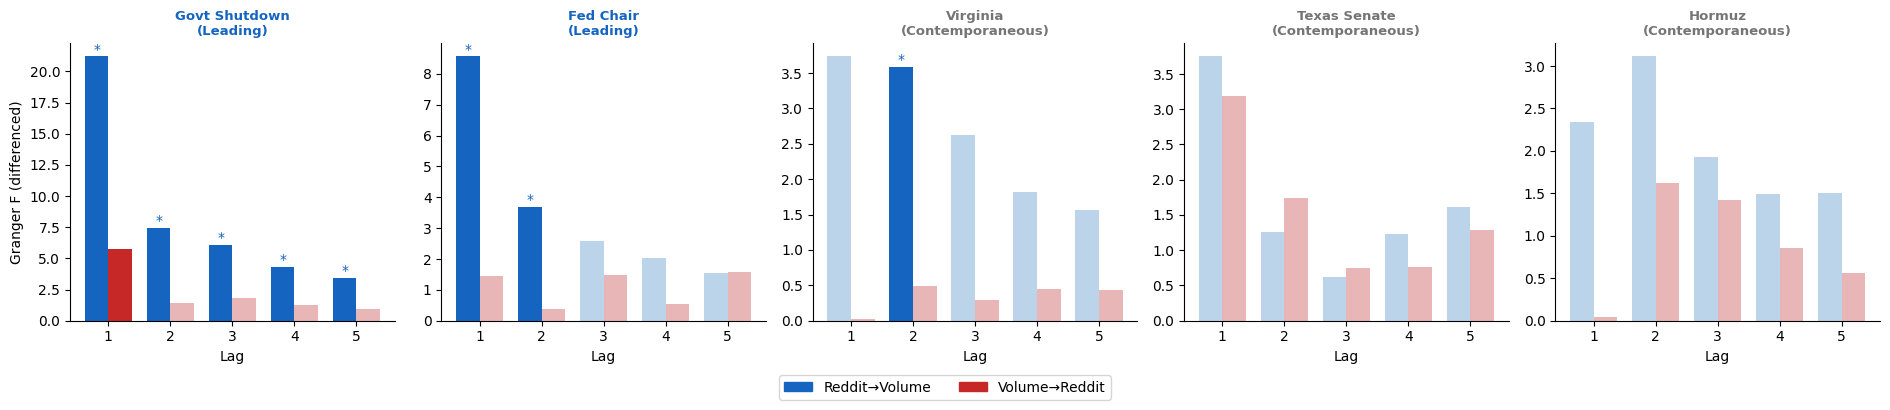

In [14]:
fig,axes=plt.subplots(1,5,figsize=(19,4))
for ax,ev in zip(axes,ORDER):
    d=market(ev); dR,dV=diffs(d); lab=LABELS[ev]; lags=list(range(1,6))
    fF=[];fP=[];rF=[];rP=[]
    for L in lags:
        F,p,_,_=granger(np.column_stack([dV,dR]),L); fF.append(F);fP.append(p)
        F2,p2,_,_=granger(np.column_stack([dR,dV]),L); rF.append(F2);rP.append(p2)
    xx=np.arange(5); w=.38
    ax.bar(xx-w/2,fF,w,color=[LEAD if p<.05 else "#BBD4EA" for p in fP])
    ax.bar(xx+w/2,rF,w,color=["#C62828" if p<.05 else "#E8B6B6" for p in rP])
    for i,p in enumerate(fP):
        if p<.05: ax.text(xx[i]-w/2,fF[i],"*",ha="center",va="bottom",color=LEAD)
    ax.set_xticks(xx); ax.set_xticklabels(lags); ax.set_xlabel("Lag")
    ax.set_title(f"{lab}\n({REGIME[lab]})",fontsize=9.5,fontweight="bold",
                 color=LEAD if REGIME[lab]=="Leading" else CONT)
    ax.spines[["top","right"]].set_visible(False)
axes[0].set_ylabel("Granger F (differenced)")
fig.legend(handles=[Patch(color=LEAD,label="Reddit→Volume"),Patch(color="#C62828",label="Volume→Reddit")],
           loc="lower center",ncol=2,bbox_to_anchor=(0.5,-0.03))
plt.tight_layout(rect=[0,0.04,1,1]); plt.show()

**A3 — Jackknife sensitivity.** Leave-one-out distribution of the same-day (lag-0)
correlation. Virginia and Texas sit far above their significance bands (robust); Hormuz sits
on its band (fragile); the leading markets are near zero (no same-day relationship).

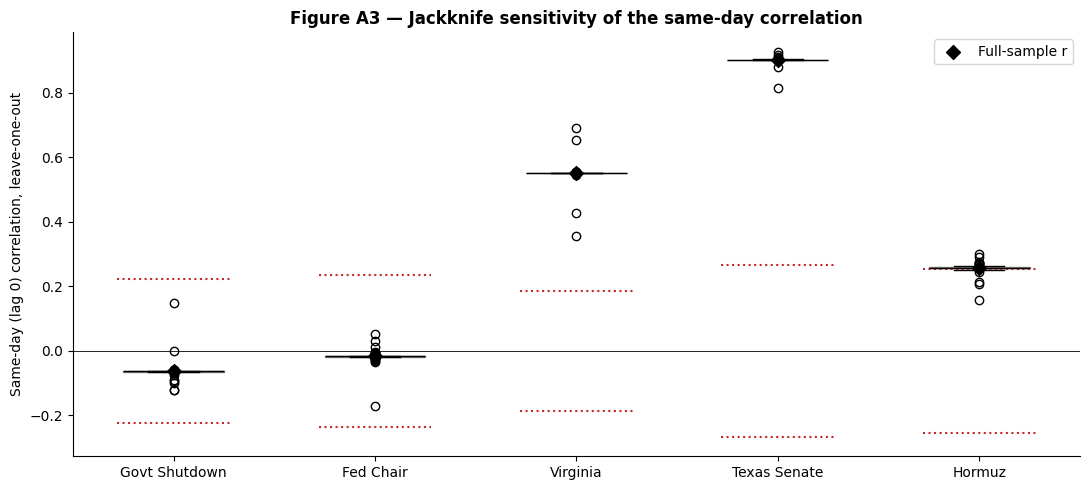

In [15]:
fig,ax=plt.subplots(figsize=(11,5))
data=[];full=[];conf=[]
for ev in ORDER:
    dR,dV=diffs(market(ev)); n=len(dR)
    full.append(stats.pearsonr(dR,dV)[0]); conf.append(1.96/np.sqrt(n))
    data.append([stats.pearsonr(np.delete(dR,i),np.delete(dV,i))[0] for i in range(n)])
pos=np.arange(5)
bp=ax.boxplot(data,positions=pos,widths=.5,patch_artist=True,medianprops=dict(color="black"))
for patch,ev in zip(bp["boxes"],ORDER):
    patch.set_facecolor(LEAD if REGIME[LABELS[ev]]=="Leading" else CONT); patch.set_alpha(.45)
ax.scatter(pos,full,marker="D",s=50,color="black",zorder=5,label="Full-sample r")
for i,c in enumerate(conf):
    ax.plot([i-.28,i+.28],[c,c],color="#C62828",ls=":"); ax.plot([i-.28,i+.28],[-c,-c],color="#C62828",ls=":")
ax.axhline(0,color="k",lw=.6); ax.set_xticks(pos); ax.set_xticklabels([LABELS[e] for e in ORDER])
ax.set_ylabel("Same-day (lag 0) correlation, leave-one-out")
ax.set_title("Figure A3 — Jackknife sensitivity of the same-day correlation",fontweight="bold")
ax.legend(); ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

## 13. Summary of findings

| Market | Verdict | Evidence (all agreeing) |
|---|---|---|
| **Govt Shutdown** | **Reddit leads by 1 day** | Diff. Granger F(1,73)=21.20, p<.001 (sustained all lags); xcorr peak +1 (r=.48); next-day R²=.23 |
| **Fed Chair** | **Reddit leads by 1 day** | Diff. Granger F(1,65)=8.56, p=.005; xcorr peak +1 (r=.38) |
| **Virginia** | **Contemporaneous** | Diff. Granger p=.056 (ns); xcorr peak lag 0 (r=.55, robust). Levels "lead" is a persistence artefact |
| **Texas Senate** | **Contemporaneous** | Diff. Granger p=.059 (ns); xcorr lag 0 (r=.90, robust to jackknife) |
| **Hormuz** | **No robust relationship** | No Granger either direction; marginal lag-0 (r=.26) that collapses under jackknife |

**Conclusion.** Reddit post volume *leads* Kalshi trading volume by one day for slowly-
developing political processes (Government Shutdown, Fed Chair confirmation) and only *co-moves
contemporaneously* for events that resolve in a discrete shock (Virginia, Texas). The Hormuz
market — the most-discussed of the five, with adequate statistical power — shows no robust
relationship at all, demonstrating that the lead is governed by **event tempo, not the volume
of attention**.